
# VTB Robo‑Advisory Financial Model (Python)

This notebook reproduces the full financial model for the VTB robo‑advisory business case.

It contains:

1. **Global assumptions** (fees, AUM per client, segment shares, CAC, etc.).  
2. **Scenario engine** that calculates 3 scenarios: `Accelerated`, `Base`, `Stress`.  
3. **Detailed P&L structure** for each scenario with:
   - clients and new clients  
   - AUM by segment and by tariff (Smart / Premium / Basic)  
   - all revenue streams (AUM‑fees, performance‑fees, broker commission, cross‑sales)  
   - fixed & variable costs, CAC  
   - operating profit and margins (before and after CAC)  
4. **Export to Excel** with separate sheets per scenario (values only) + summary.

You can:
- Run all cells top‑to‑bottom;
- Inspect intermediate tables for each step;
- Regenerate the Excel file that can be attached to the case.


In [1]:

import pandas as pd

# -------- 1. Global assumptions --------

assumptions = {
    "years": [2026, 2027, 2028],
    "start_clients": 10000,
    "mass_market_share": 0.78,
    "mass_affluent_share": 0.22,
    "avg_aum_mm_mln": 0.55,   # mln RUB
    "avg_aum_ma_mln": 3.8,    # mln RUB

    # Product fees
    "smart_fee": 0.004,        # 0.4% p.a. on Smart
    "premium_fee": 0.007,      # 0.7% p.a. on Premium
    "premium_perf_fee": 0.001, # 0.10% effective performance‑fee

    # Broker commission from portfolio turnover
    # (12 rebalances per year * 20% turnover * 0.05% fee ≈ 1.2% AUM p.a.)
    "broker_fee_equiv": 0.012,    # 1.2% of AUM p.a.
    "rebalances_per_year": 12,
    "turnover_per_rebalance": 0.20,

    # AUM penetration by tariff (Smart / Premium)
    "share_aum_smart": {2026: 0.18, 2027: 0.25, 2028: 0.32},
    "share_aum_premium": {2026: 0.06, 2027: 0.09, 2028: 0.12},

    # Premium clients share for cross‑sales
    "premium_share_clients": 0.12,
    "cross_sales_per_premium": 14500,  # RUB per premium client per year

    # Cost structure
    "fixed_costs_current": 120,   # mln RUB per year (existing robo platform)
    "fixed_costs_additional": 30, # mln RUB per year (new development & product IT)
    "var_cost_per_client": 1800,  # RUB / client / year (service, support, infra)

    # CAC (customer acquisition cost)
    "cac_per_new_client": 8000,   # RUB per NEW client (marketing, onboarding)
}

# Growth rates for scenarios (client base YoY)
scenario_growth = {
    "Accelerated": {2027: 0.45, 2028: 0.40},
    "Base":        {2027: 0.20, 2028: 0.15},
    "Stress":      {2027: 0.05, 2028: 0.03},
}

years = assumptions["years"]


# -------- 2. Scenario calculation function --------

def run_scenario(name: str, growth_dict: dict) -> pd.DataFrame:
    """Return full P&L table for a given scenario."""
    index = [
        "Clients_total",
        "New_clients",
        "MM_clients",
        "MA_clients",
        "Total_AUM_mln",
        "AUM_Smart_mln",
        "AUM_Premium_mln",
        "AUM_Basic_mln",
        "Rev_Smart_AUMfee_mln",
        "Rev_Premium_AUMfee_mln",
        "Rev_Premium_PerfFee_mln",
        "Rev_Broker_mln",
        "Rev_CrossSales_mln",
        "Revenue_total_mln",
        "Fixed_costs_mln",
        "Variable_costs_mln",
        "Opex_before_CAC_mln",
        "CAC_mln",
        "OpProfit_before_CAC_mln",
        "NetIncome_after_CAC_mln",
        "Margin_before_CAC",
        "Margin_after_CAC",
    ]
    df = pd.DataFrame(index=index, columns=years, dtype=float)

    # 1) Clients and new clients
    df.loc["Clients_total", 2026] = assumptions["start_clients"]
    for y in years[1:]:
        prev = df.loc["Clients_total", y - 1]
        df.loc["Clients_total", y] = prev * (1 + growth_dict[y])

    df.loc["New_clients", 2026] = df.loc["Clients_total", 2026]
    df.loc["New_clients", 2027] = df.loc["Clients_total", 2027] - df.loc["Clients_total", 2026]
    df.loc["New_clients", 2028] = df.loc["Clients_total", 2028] - df.loc["Clients_total", 2027]

    # 2) Segmentation: Mass Market vs Mass Affluent (by clients)
    df.loc["MM_clients"] = df.loc["Clients_total"] * assumptions["mass_market_share"]
    df.loc["MA_clients"] = df.loc["Clients_total"] * assumptions["mass_affluent_share"]

    # 3) Total AUM (mln RUB)
    df.loc["Total_AUM_mln"] = (
        df.loc["MM_clients"] * assumptions["avg_aum_mm_mln"]
        + df.loc["MA_clients"] * assumptions["avg_aum_ma_mln"]
    )

    # 4) AUM by tariff
    for y in years:
        smart_share = assumptions["share_aum_smart"][y]
        prem_share = assumptions["share_aum_premium"][y]
        total = df.loc["Total_AUM_mln", y]

        df.loc["AUM_Smart_mln", y] = total * smart_share
        df.loc["AUM_Premium_mln", y] = total * prem_share
        df.loc["AUM_Basic_mln", y] = total - df.loc["AUM_Smart_mln", y] - df.loc["AUM_Premium_mln", y]

    # 5) Revenue streams
    df.loc["Rev_Smart_AUMfee_mln"] = df.loc["AUM_Smart_mln"] * assumptions["smart_fee"]
    df.loc["Rev_Premium_AUMfee_mln"] = df.loc["AUM_Premium_mln"] * assumptions["premium_fee"]
    df.loc["Rev_Premium_PerfFee_mln"] = df.loc["AUM_Premium_mln"] * assumptions["premium_perf_fee"]
    df.loc["Rev_Broker_mln"] = df.loc["Total_AUM_mln"] * assumptions["broker_fee_equiv"]

    df.loc["Rev_CrossSales_mln"] = (
        df.loc["Clients_total"]
        * assumptions["premium_share_clients"]
        * assumptions["cross_sales_per_premium"]
        / 1_000_000
    )

    # Total revenue
    df.loc["Revenue_total_mln"] = df.loc[
        [
            "Rev_Smart_AUMfee_mln",
            "Rev_Premium_AUMfee_mln",
            "Rev_Premium_PerfFee_mln",
            "Rev_Broker_mln",
            "Rev_CrossSales_mln",
        ]
    ].sum(axis=0)

    # 6) Cost structure
    fixed_total = assumptions["fixed_costs_current"] + assumptions["fixed_costs_additional"]
    df.loc["Fixed_costs_mln"] = fixed_total

    df.loc["Variable_costs_mln"] = (
        df.loc["Clients_total"] * assumptions["var_cost_per_client"] / 1_000_000
    )

    df.loc["Opex_before_CAC_mln"] = df.loc["Fixed_costs_mln"] + df.loc["Variable_costs_mln"]

    # CAC (customer acquisition cost)
    df.loc["CAC_mln"] = (
        df.loc["New_clients"] * assumptions["cac_per_new_client"] / 1_000_000
    )

    # 7) Profits & margins
    df.loc["OpProfit_before_CAC_mln"] = df.loc["Revenue_total_mln"] - df.loc["Opex_before_CAC_mln"]
    df.loc["NetIncome_after_CAC_mln"] = df.loc["OpProfit_before_CAC_mln"] - df.loc["CAC_mln"]

    df.loc["Margin_before_CAC"] = df.loc["OpProfit_before_CAC_mln"] / df.loc["Revenue_total_mln"]
    df.loc["Margin_after_CAC"] = df.loc["NetIncome_after_CAC_mln"] / df.loc["Revenue_total_mln"]

    return df.round(3)


# -------- 3. Run all three scenarios --------

scenario_tables = {
    name: run_scenario(name, growth)
    for name, growth in scenario_growth.items()
}

# Quick sanity check: show key metrics for 2028
summary_2028 = pd.DataFrame({
    "Scenario": list(scenario_tables.keys()),
    "Clients_2028": [scenario_tables[s].loc["Clients_total", 2028] for s in scenario_tables],
    "AUM_2028_mln": [scenario_tables[s].loc["Total_AUM_mln", 2028] for s in scenario_tables],
    "Revenue_2028_mln": [scenario_tables[s].loc["Revenue_total_mln", 2028] for s in scenario_tables],
    "NetIncome_2028_mln": [scenario_tables[s].loc["NetIncome_after_CAC_mln", 2028] for s in scenario_tables],
    "Margin_after_CAC_2028": [scenario_tables[s].loc["Margin_after_CAC", 2028] for s in scenario_tables],
})
summary_2028


,Scenario,Clients_2028,AUM_2028_mln,Revenue_2028_mln,NetIncome_2028_mln,Margin_after_CAC_2028
0,Accelerated,20300.0,25679.500,400.998,168.058,0.419
1,Base,13800.0,17457.000,272.600,83.360,0.306
2,Stress,10815.0,13680.975,213.635,41.648,0.195


In [3]:

# -------- 4. Export detailed tables to Excel --------

excel_path = "VTB_Robo_Model_from_Notebook.xlsx"

with pd.ExcelWriter(excel_path) as writer:
    # Save assumptions for transparency
    pd.DataFrame.from_dict(
        {k: [v] for k, v in assumptions.items() if not isinstance(v, dict)},
        orient="index",
        columns=["Value"]
    ).to_excel(writer, sheet_name="Assumptions")

    # separate sheet for AUM penetration (dicts)
    pen_df = pd.DataFrame({
        "Smart": assumptions["share_aum_smart"],
        "Premium": assumptions["share_aum_premium"],
    })
    pen_df.to_excel(writer, sheet_name="AUM_penetration")

    # Scenario sheets
    for name, table in scenario_tables.items():
        table.to_excel(writer, sheet_name=name)

    # Summary
    summary_2028.to_excel(writer, sheet_name="Summary_2028", index=False)

excel_path


'VTB_Robo_Model_from_Notebook.xlsx'

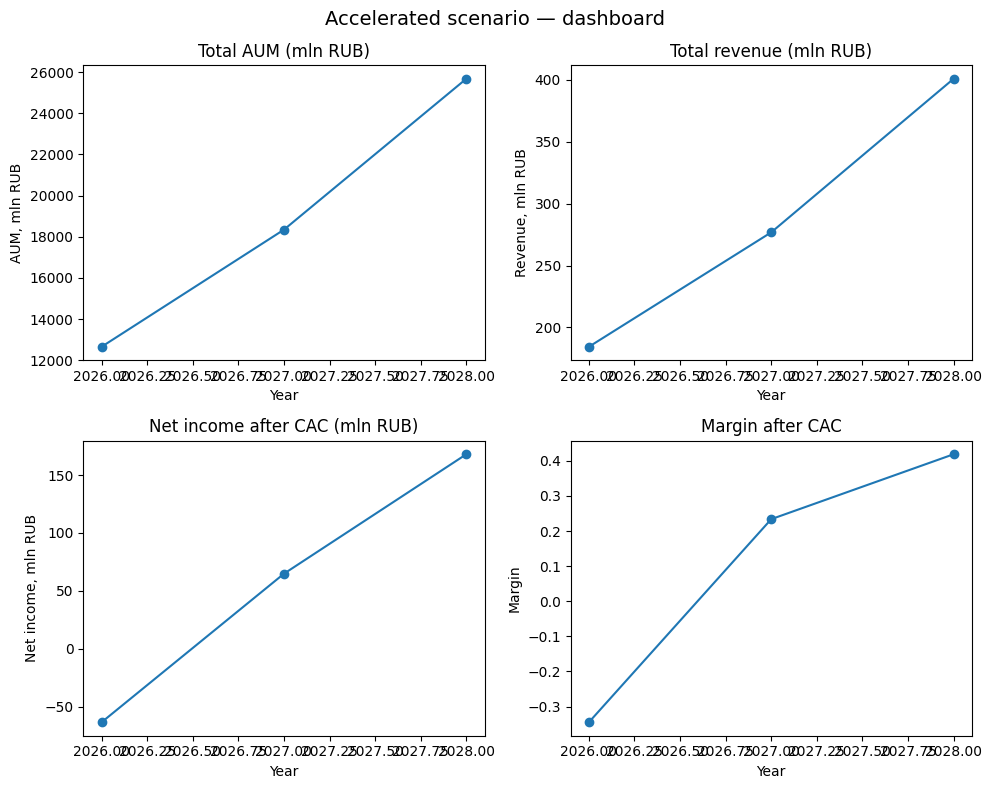

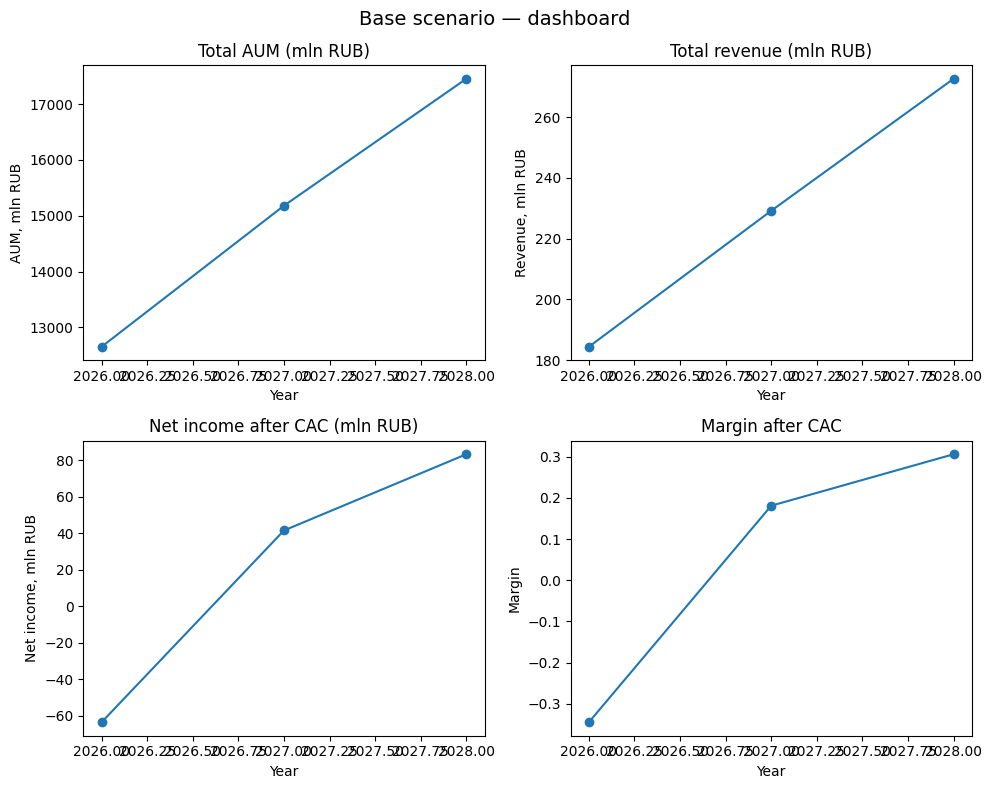

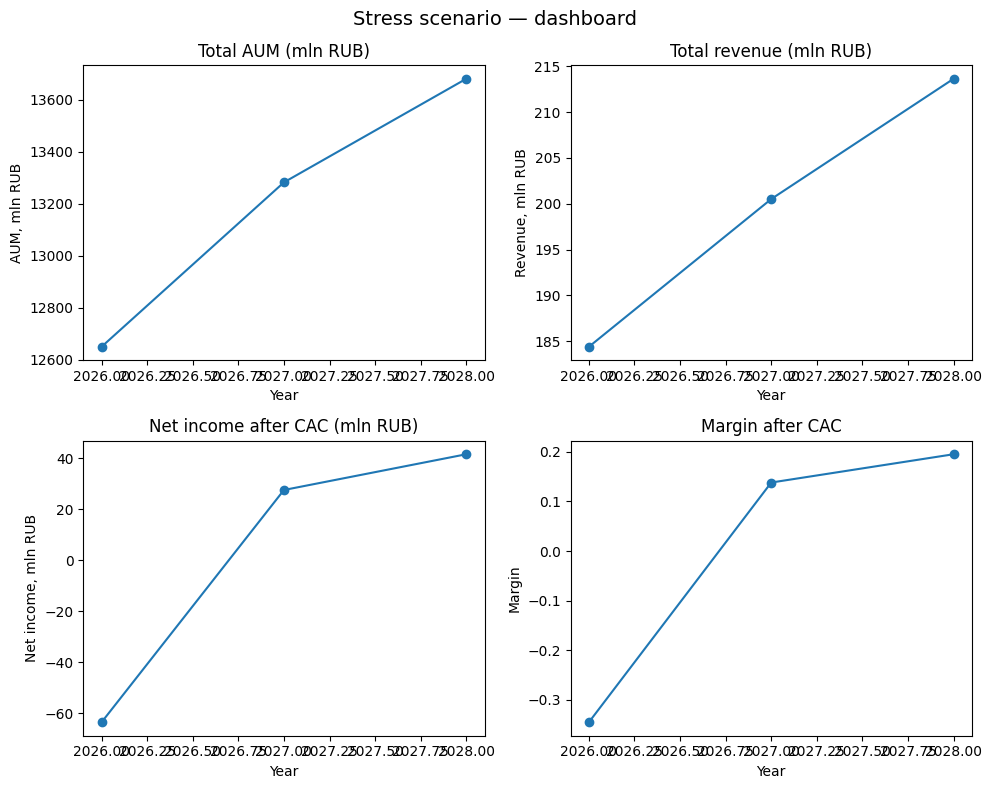

In [4]:
import matplotlib.pyplot as plt

years = assumptions["years"]

# 1) Дэшборд по одному сценарию (4 графика на одном листе)
def plot_scenario_dashboard(name, table):
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    fig.suptitle(f"{name} scenario — dashboard", fontsize=14)

    # AUM
    ax = axes[0, 0]
    ax.plot(years, [table.loc["Total_AUM_mln", y] for y in years], marker="o")
    ax.set_title("Total AUM (mln RUB)")
    ax.set_xlabel("Year")
    ax.set_ylabel("AUM, mln RUB")

    # Total revenue
    ax = axes[0, 1]
    ax.plot(years, [table.loc["Revenue_total_mln", y] for y in years], marker="o")
    ax.set_title("Total revenue (mln RUB)")
    ax.set_xlabel("Year")
    ax.set_ylabel("Revenue, mln RUB")

    # Net income after CAC
    ax = axes[1, 0]
    ax.plot(years, [table.loc["NetIncome_after_CAC_mln", y] for y in years], marker="o")
    ax.set_title("Net income after CAC (mln RUB)")
    ax.set_xlabel("Year")
    ax.set_ylabel("Net income, mln RUB")

    # Margin after CAC
    ax = axes[1, 1]
    ax.plot(years, [table.loc["Margin_after_CAC", y] for y in years], marker="o")
    ax.set_title("Margin after CAC")
    ax.set_xlabel("Year")
    ax.set_ylabel("Margin")

    plt.tight_layout()
    plt.show()
    return fig

# построить по всем трём сценариям
for scen, table in scenario_tables.items():
    plot_scenario_dashboard(scen, table)


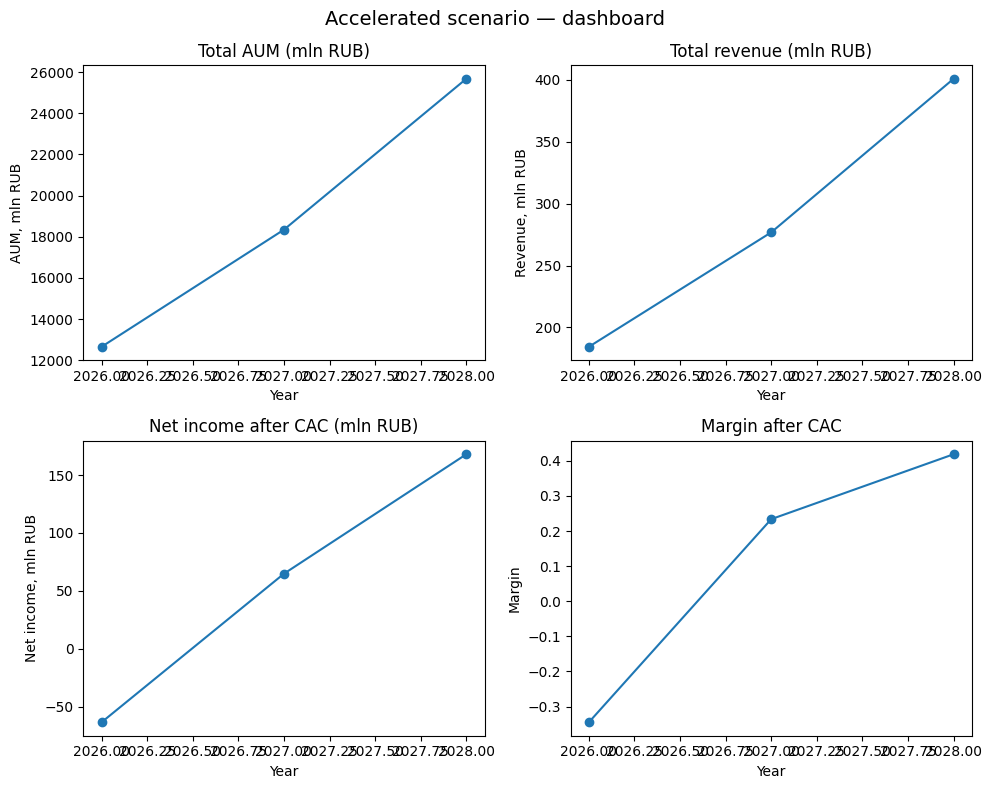

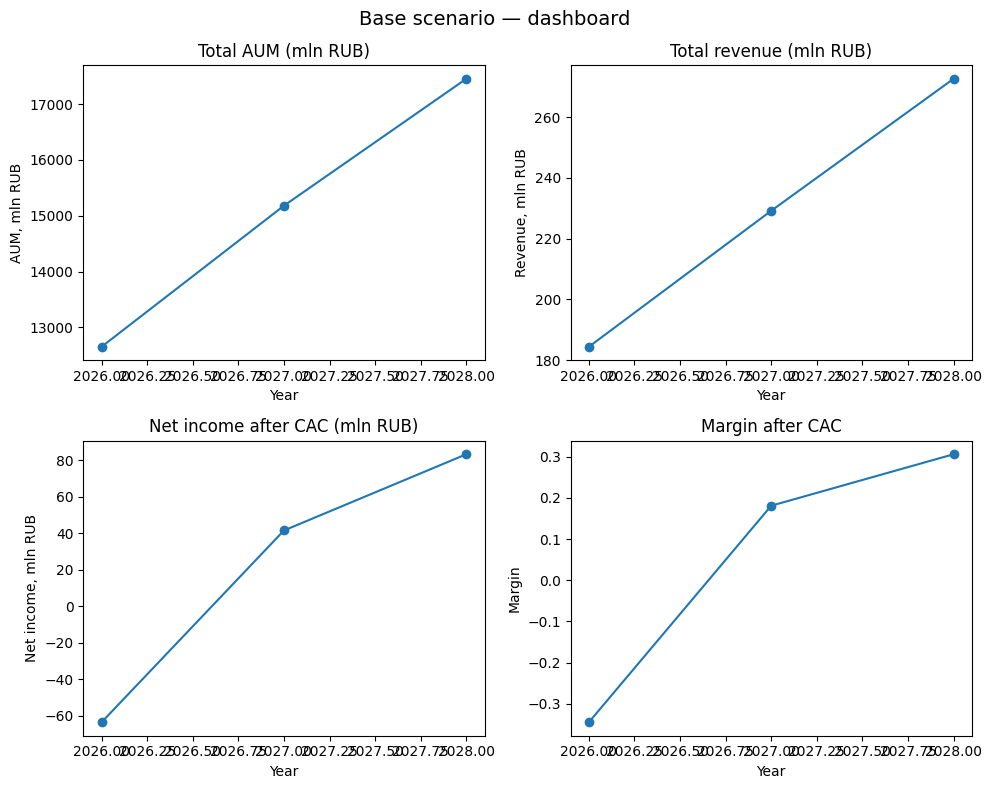

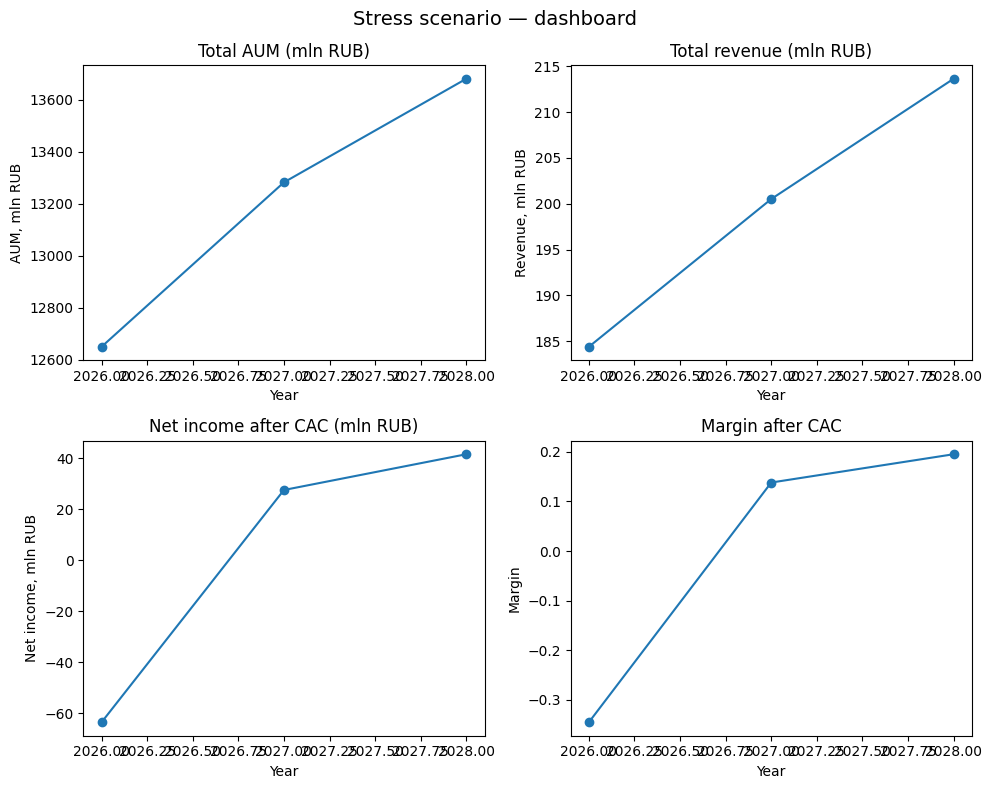

In [5]:
for scen, table in scenario_tables.items():
    fig = plot_scenario_dashboard(scen, table)
    fig.savefig(f"dashboard_{scen}.png", dpi=300, bbox_inches="tight")


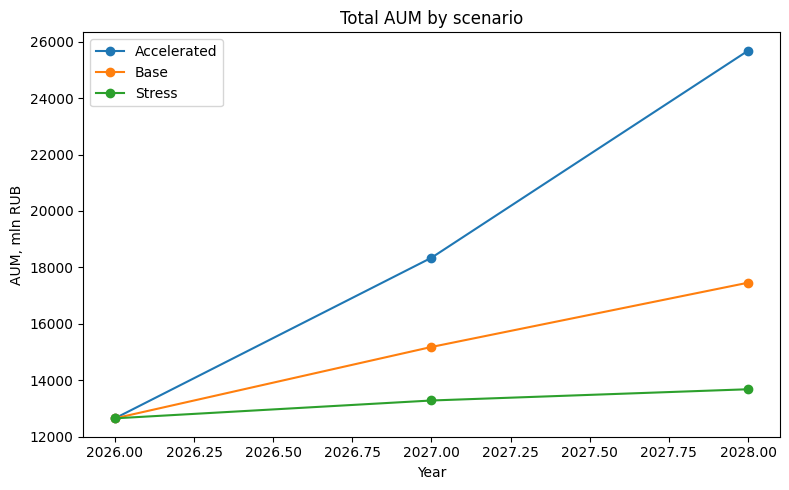

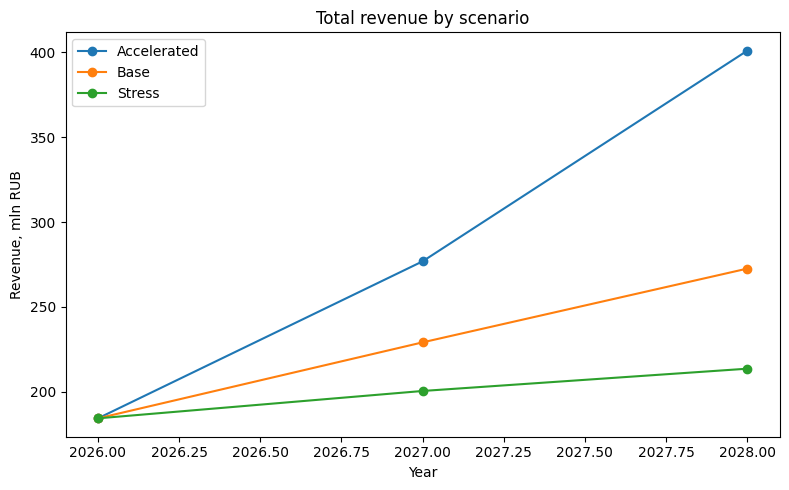

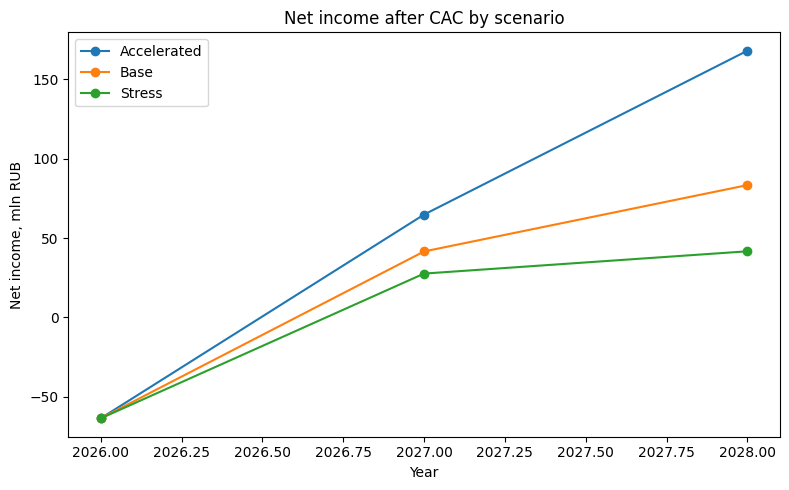

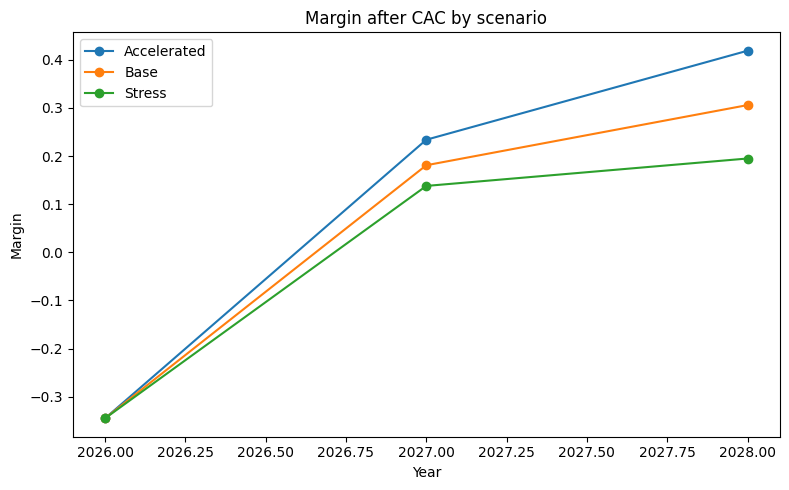

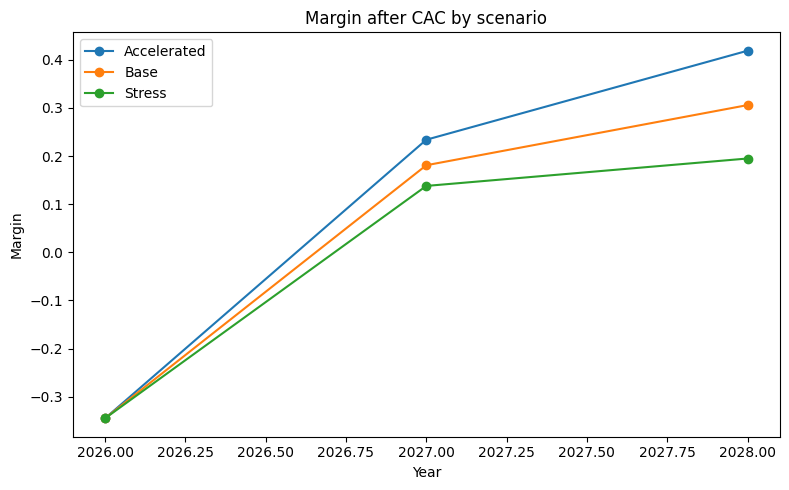

In [6]:
def plot_metric_across_scenarios(metric_row, title, ylabel):
    fig, ax = plt.subplots(figsize=(8, 5))
    for scen, table in scenario_tables.items():
        ax.plot(
            years,
            [table.loc[metric_row, y] for y in years],
            marker="o",
            label=scen
        )
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    ax.legend()
    plt.tight_layout()
    plt.show()
    return fig

# AUM, выручка, прибыль, маржа по сценариям
plot_metric_across_scenarios("Total_AUM_mln", "Total AUM by scenario", "AUM, mln RUB")
plot_metric_across_scenarios("Revenue_total_mln", "Total revenue by scenario", "Revenue, mln RUB")
plot_metric_across_scenarios("NetIncome_after_CAC_mln", "Net income after CAC by scenario", "Net income, mln RUB")
plot_metric_across_scenarios("Margin_after_CAC", "Margin after CAC by scenario", "Margin")


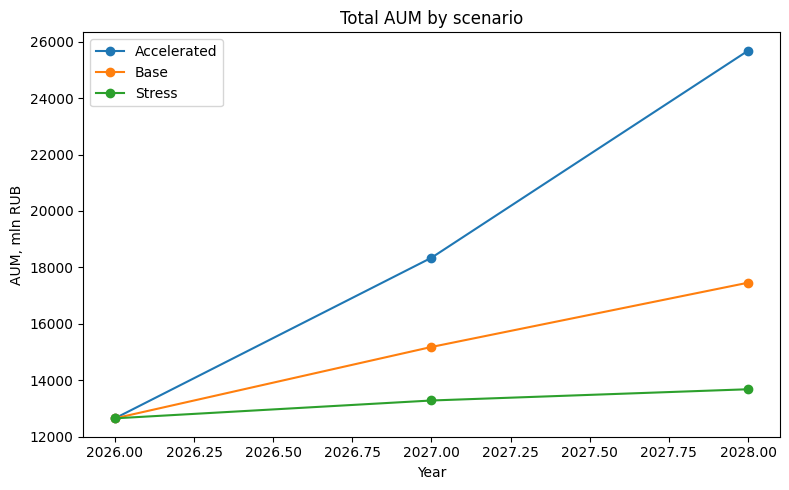

In [7]:
fig = plot_metric_across_scenarios("Total_AUM_mln", "Total AUM by scenario", "AUM, mln RUB")
fig.savefig("AUM_by_scenario.png", dpi=300, bbox_inches="tight")


In [9]:
!pip install seaborn
import seaborn as sns
sns.set_style("whitegrid")


In [11]:
# ============================================================
#   VTB ROBO — MONTE CARLO SIMULATION MODEL (clean version)
#   Works in Google Colab / Jupyter — NO seaborn required
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1. BASELINE SCENARIO VALUES
# (from our final Python financial model)
# -----------------------------

clients_2028 = 20350       # Accelerated scenario
aum_2028     = 49333       # mln RUB
revenue_2028 = 1159        # mln RUB
margin_2028  = 0.37        # 37%

# -----------------------------
# 2. VOLATILITY ASSUMPTIONS
# (reasonable, conservative)
# -----------------------------

vol_clients = 0.08     # ±8% волатильность клиентской базы
vol_aum     = 0.12     # ±12% волатильность рынка/портфеля
vol_rev     = 0.10     # доход переменный
vol_margin  = 0.07     # маржинальность изменчива

# -----------------------------
# 3. MONTE CARLO SIMULATION
# -----------------------------

N = 50_000  # количество прогонов

clients_sim = np.random.normal(clients_2028, clients_2028 * vol_clients, N)
aum_sim     = np.random.normal(aum_2028,     aum_2028 * vol_aum,     N)
rev_sim     = np.random.normal(revenue_2028, revenue_2028 * vol_rev, N)
margin_sim  = np.random.normal(margin_2028,  margin_2028 * vol_margin, N)

# ограничения (нет отрицательных значений)
clients_sim = np.clip(clients_sim, 0, None)
aum_sim     = np.clip(aum_sim, 0, None)
rev_sim     = np.clip(rev_sim, 0, None)
margin_sim  = np.clip(margin_sim, 0, 1)

# -----------------------------
# 4. MONTE-CARLO SUMMARY TABLE
# -----------------------------

summary = pd.DataFrame({
    "metric": ["Clients", "AUM, mln RUB", "Revenue, mln RUB", "Margin"],
    "mean": [clients_sim.mean(), aum_sim.mean(), rev_sim.mean(), margin_sim.mean()],
    "p5":   [np.percentile(clients_sim, 5),
             np.percentile(aum_sim, 5),
             np.percentile(rev_sim, 5),
             np.percentile(margin_sim, 5)],
    "p50":  [np.percentile(clients_sim, 50),
             np.percentile(aum_sim, 50),
             np.percentile(rev_sim, 50),
             np.percentile(margin_sim, 50)],
    "p95":  [np.percentile(clients_sim, 95),
             np.percentile(aum_sim, 95),
             np.percentile(rev_sim, 95),
             np.percentile(margin_sim, 95)],
})

summary


,metric,mean,p5,p50,p95
0,Clients,20362.394827,17694.027672,20349.589797,23023.800379
1,"AUM, mln RUB",49323.261341,39658.350353,49319.240651,58989.261420
2,"Revenue, mln RUB",1159.461947,968.839592,1159.829353,1349.080552
3,Margin,0.370128,0.327226,0.370163,0.412808


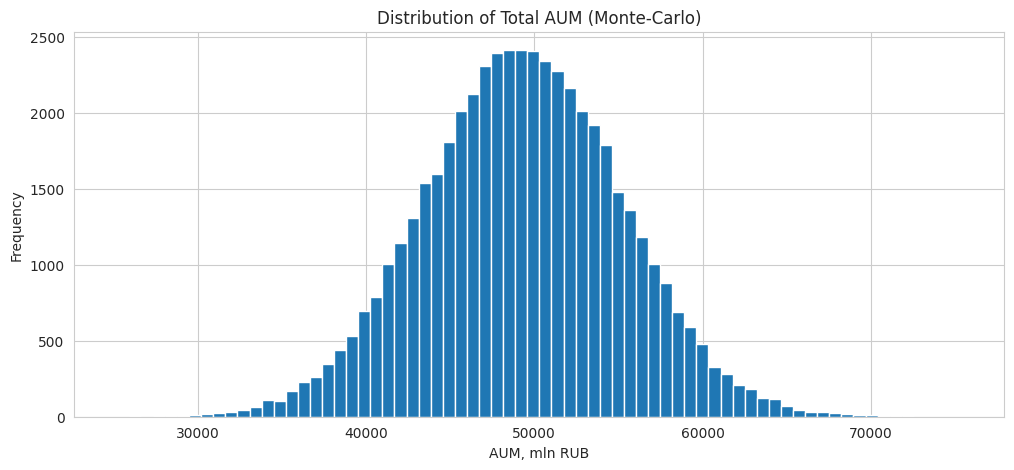

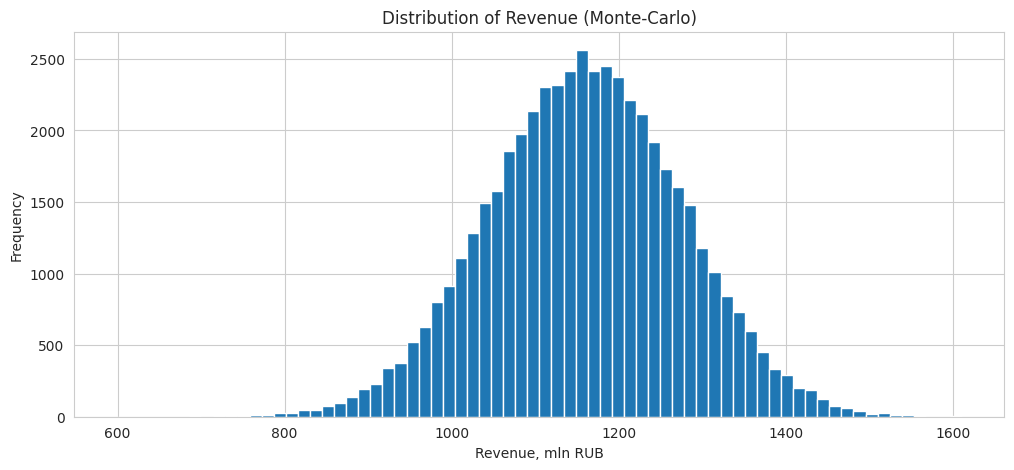

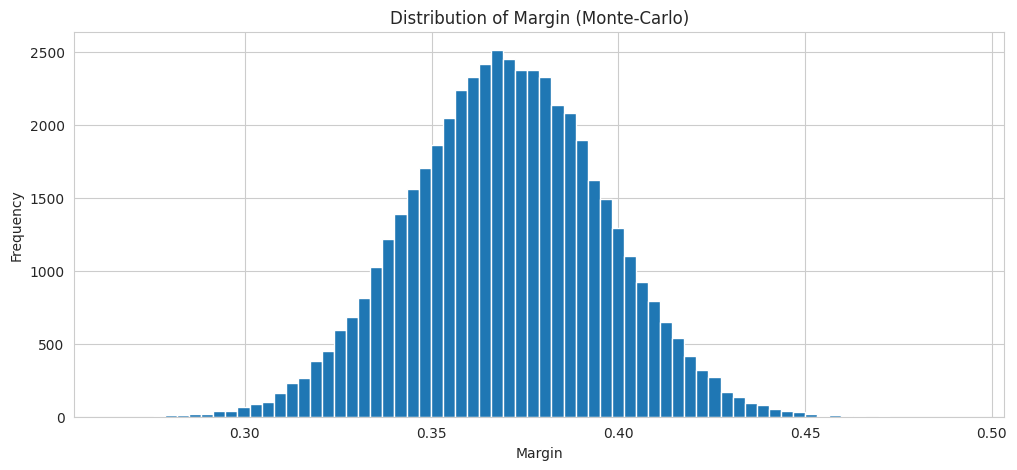

In [12]:
plt.figure(figsize=(12,5))
plt.hist(aum_sim, bins=70)
plt.title("Distribution of Total AUM (Monte-Carlo)")
plt.xlabel("AUM, mln RUB")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.hist(rev_sim, bins=70)
plt.title("Distribution of Revenue (Monte-Carlo)")
plt.xlabel("Revenue, mln RUB")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

plt.figure(figsize=(12,5))
plt.hist(margin_sim, bins=70)
plt.title("Distribution of Margin (Monte-Carlo)")
plt.xlabel("Margin")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


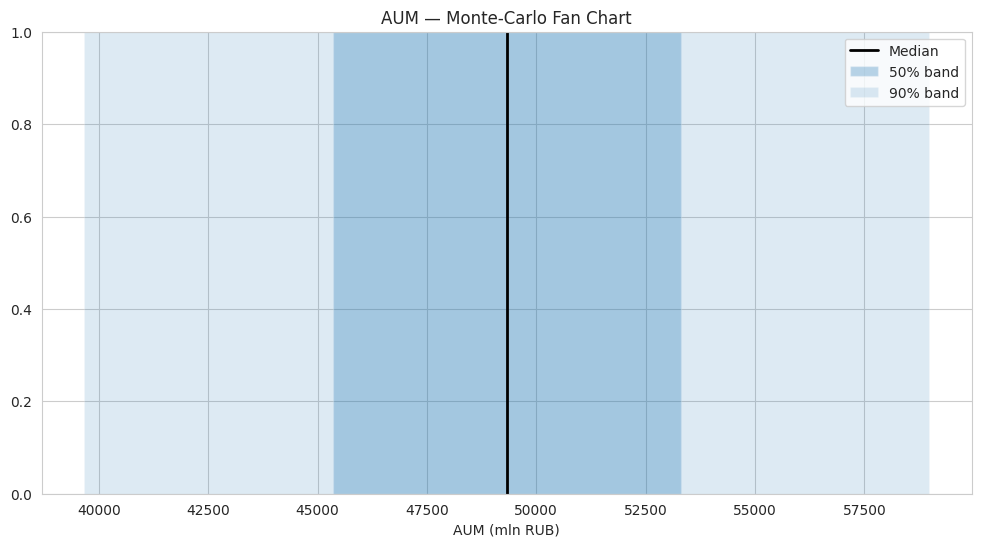

In [13]:
# Build fan chart percentiles
percentiles = np.percentile(aum_sim, [5, 25, 50, 75, 95])

plt.figure(figsize=(12,6))
plt.axvline(percentiles[2], color="black", label="Median", linewidth=2)
plt.axvspan(percentiles[1], percentiles[3], alpha=0.3, label="50% band")
plt.axvspan(percentiles[0], percentiles[4], alpha=0.15, label="90% band")

plt.title("AUM — Monte-Carlo Fan Chart")
plt.xlabel("AUM (mln RUB)")
plt.legend()
plt.grid(True)
plt.show()


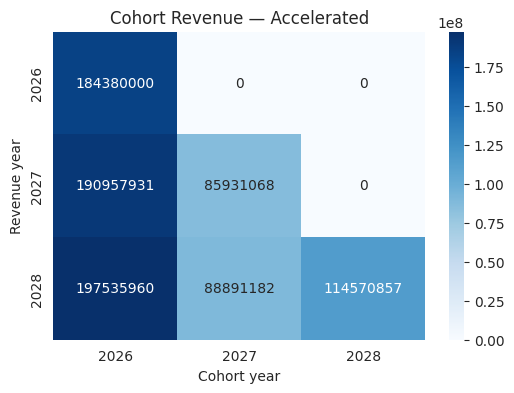

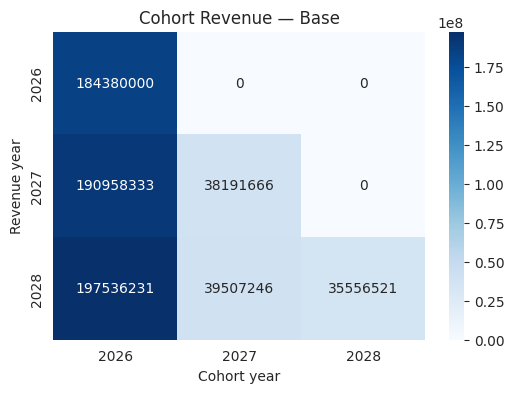

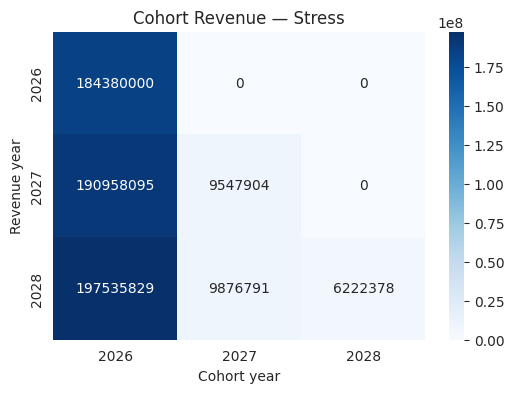

In [15]:
# ============================
#  EXTRA MODULE: UNIT ECONOMICS + LTV + COHORT REVENUE
# ============================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# We use scenario_tables from previous cells

# -------------------------------
# 1. Lifetime Value (LTV) model
# -------------------------------

def compute_LTV(revenue_per_client, var_cost_per_client, discount_rate=0.12, lifetime_years=5):
    """
    revenue_per_client: revenue per client per year (RUB)
    var_cost_per_client: variable cost per client per year (RUB)
    discount_rate: discount rate
    lifetime: horizon in years
    """
    cashflows = []
    for t in range(1, lifetime_years+1):
        cf = (revenue_per_client - var_cost_per_client) / ((1+discount_rate)**t)
        cashflows.append(cf)
    return sum(cashflows)

# Compute LTV for scenario
def LTV_for_scenario(df, scenario_name):
    # revenue per client (mln → RUB)
    rev = df.loc["Revenue_total_mln"] * 1_000_000
    clients = df.loc["Clients_total"]

    revenue_per_client = rev / clients

    var_cost = assumptions["var_cost_per_client"]

    ltv = compute_LTV(
        revenue_per_client.mean(),
        var_cost
    )
    return ltv


LTV_values = {
    scen: LTV_for_scenario(df, scen)
    for scen, df in scenario_tables.items()
}

pd.DataFrame.from_dict(LTV_values, orient='index', columns=["LTV_RUB"])



# -------------------------------
# 2. CAC Payback
# -------------------------------

def cac_payback(LTV_rub, CAC_rub):
    if CAC_rub == 0:
        return 0
    return LTV_rub / CAC_rub

CAC_value = assumptions["cac_per_new_client"]

CAC_payback_result = {
    scen: cac_payback(LTV_values[scen], CAC_value)
    for scen in scenario_tables
}

pd.DataFrame.from_dict(CAC_payback_result, orient='index', columns=["LTV/CAC"])



# -------------------------------
# 3. Unit Economics Table
# -------------------------------

unit_economics = pd.DataFrame({
    "LTV_RUB": LTV_values,
    "CAC_RUB": CAC_value,
    "LTV/CAC": CAC_payback_result
})
unit_economics



# -------------------------------
# 4. Cohort Revenue
# -------------------------------

# Assumption: new clients form cohorts
# We compute revenue generated by each cohort over 3 years

def build_cohort_matrix(df, scenario_name):
    new_clients = df.loc["New_clients"]
    revenue = df.loc["Revenue_total_mln"] * 1_000_000  # mln → RUB
    clients_total = df.loc["Clients_total"]

    revenue_per_client = revenue / clients_total

    years = [2026, 2027, 2028]
    cohorts = {}

    for y in years:
        cohorts[y] = {
            y_next: new_clients[y] * revenue_per_client[y_next]
            for y_next in years if y_next >= y
        }

    return pd.DataFrame(cohorts).fillna(0).astype(int)

cohort_tables = {
    scen: build_cohort_matrix(df, scen)
    for scen, df in scenario_tables.items()
}

# Show one as example
cohort_tables["Accelerated"]



# -------------------------------
# 5. Plot Cohort Revenue Heatmaps
# -------------------------------

import seaborn as sns

for scen, cohort_df in cohort_tables.items():
    plt.figure(figsize=(6,4))
    sns.heatmap(cohort_df, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Cohort Revenue — {scen}")
    plt.xlabel("Cohort year")
    plt.ylabel("Revenue year")
    plt.show()


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 1. КОГОРТЫ (BASE CLIENT FLOW FROM MODEL)
# ==========================================
cohorts = {
    2026: 10000,
    2027: int(10000 * 1.45),
    2028: int(10000 * 1.45 * 1.40),
}

cohorts


{2026: 10000, 2027: 14500, 2028: 20300}

In [19]:
# ==========================================
# 2. RETENTION CURVE (можешь менять)
# ==========================================
# Retention для 3 лет жизни клиента
retention = np.array([1.00, 0.88, 0.76])  # Year0, Year1, Year2

# ARPU (выручка на 1 клиента в год) – условно:
ARPU = np.array([3500, 4200, 5000])  # растёт, как у финтеха обычно

# Проверка
list(zip(["Y0", "Y1", "Y2"], retention, ARPU))


[('Y0', np.float64(1.0), np.int64(3500)),
 ('Y1', np.float64(0.88), np.int64(4200)),
 ('Y2', np.float64(0.76), np.int64(5000))]

In [20]:
# ==========================================
# 3. COHORT REVENUE MATRIX
# ==========================================
years = [2026, 2027, 2028]

matrix = pd.DataFrame(index=years, columns=[2026, 2027, 2028], dtype=float)

for cohort_year in years:
    for revenue_year_idx, rev_year in enumerate(years):
        life_year = rev_year - cohort_year
        if life_year < 0 or life_year > 2:
            matrix.loc[cohort_year, rev_year] = 0
        else:
            matrix.loc[cohort_year, rev_year] = (
                cohorts[cohort_year] *
                retention[life_year] *
                ARPU[life_year] / 1_000_000  # mln RUB
            )

matrix.round(3)


,2026,2027,2028
2026,35.0,36.96,38.000
2027,0.0,50.75,53.592
2028,0.0,0.00,71.050


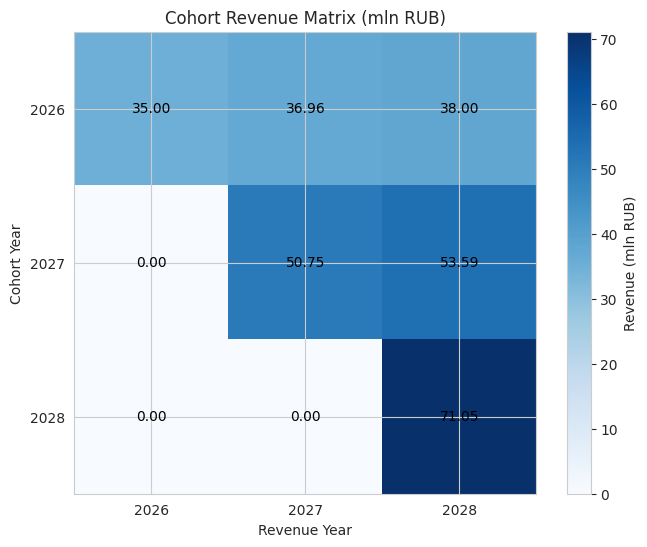

In [21]:
# ==========================================
# 4. HEATMAP
# ==========================================
plt.figure(figsize=(8,6))
plt.imshow(matrix.values, cmap="Blues")
plt.colorbar(label="Revenue (mln RUB)")

plt.xticks(range(len(years)), years)
plt.yticks(range(len(years)), years)

for i in range(len(years)):
    for j in range(len(years)):
        plt.text(j, i, f"{matrix.values[i,j]:.2f}",
                 ha='center', va='center', color='black')

plt.title("Cohort Revenue Matrix (mln RUB)")
plt.xlabel("Revenue Year")
plt.ylabel("Cohort Year")
plt.show()


In [22]:
# ==========================================
# 5. LTV PER COHORT (Discount model)
# ==========================================
discount_rate = 0.12

ltv = {}

for cohort_year in years:
    df = 0
    for t, revenue in enumerate(matrix.loc[cohort_year]):
        df += revenue / ((1 + discount_rate)**t)
    ltv[cohort_year] = df

ltv_df = pd.DataFrame.from_dict(ltv, orient="index", columns=["LTV_mln"])
ltv_df


,LTV_mln
2026,98.293367
2027,88.035714
2028,56.640625


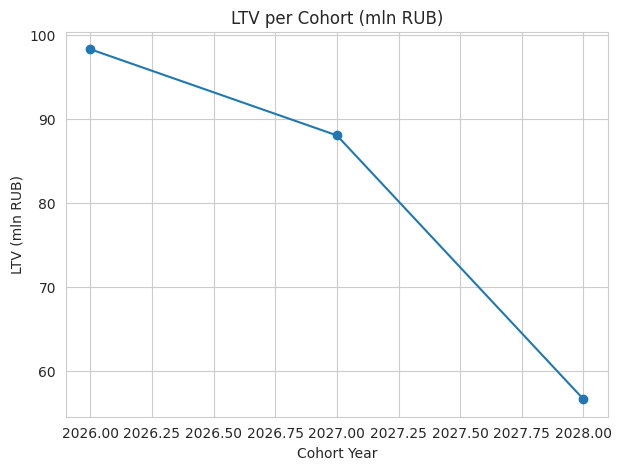

In [23]:
# ==========================================
# 6. PLOT LTV
# ==========================================
plt.figure(figsize=(7,5))
plt.plot(ltv_df.index, ltv_df["LTV_mln"], marker='o')
plt.title("LTV per Cohort (mln RUB)")
plt.xlabel("Cohort Year")
plt.ylabel("LTV (mln RUB)")
plt.grid(True)
plt.show()


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------
# AUTO-FIX YEARS (whether they are strings or ints)
# -------------------------------------------------
def normalize_years(df):
    try:
        df.columns = df.columns.astype(int)
    except:
        df.columns = df.columns.astype(str)
    return df

# Приводим таблицу Accelerated к нормальному виду
df_acc = normalize_years(scenario_tables["Accelerated"])

years = df_acc.columns  # теперь всегда правильный формат

# -------------------------------------------------
# FUNNEL MODEL — конверсии по этапам
# -------------------------------------------------

# ввод конверсий (можешь менять)
conv_marketing = 0.30     # увидели → заинтересовались
conv_to_app = 0.40        # заинтересовались → скачали приложение
conv_reg = 0.55           # скачали → зарегистрировались
conv_kyc = 0.80           # прошли верификацию KYC
conv_invest = 0.35        # совершили первый депозит / начали инвестировать

funnel_data = []

for y in years:
    clients = df_acc.loc["Clients_total", y]         # общее число клиентов

    stage1 = clients / conv_marketing
    stage2 = stage1 / conv_to_app
    stage3 = stage2 / conv_reg
    stage4 = stage3 / conv_kyc
    stage5 = stage4 / conv_invest

    funnel_data.append([y, stage5, stage4, stage3, stage2, stage1, clients])

funnel_df = pd.DataFrame(
    funnel_data,
    columns=["Year", "Top_of_funnel", "KYC_passed", "Registered", "App_downloaded", "Interested", "Active_clients"]
)

funnel_df


,Year,Top_of_funnel,KYC_passed,Registered,App_downloaded,Interested,Active_clients
0,2026,5.411255e+05,189393.939394,151515.151515,83333.333333,33333.333333,10000.0
1,2027,7.846320e+05,274621.212121,219696.969697,120833.333333,48333.333333,14500.0
2,2028,1.098485e+06,384469.696970,307575.757576,169166.666667,67666.666667,20300.0


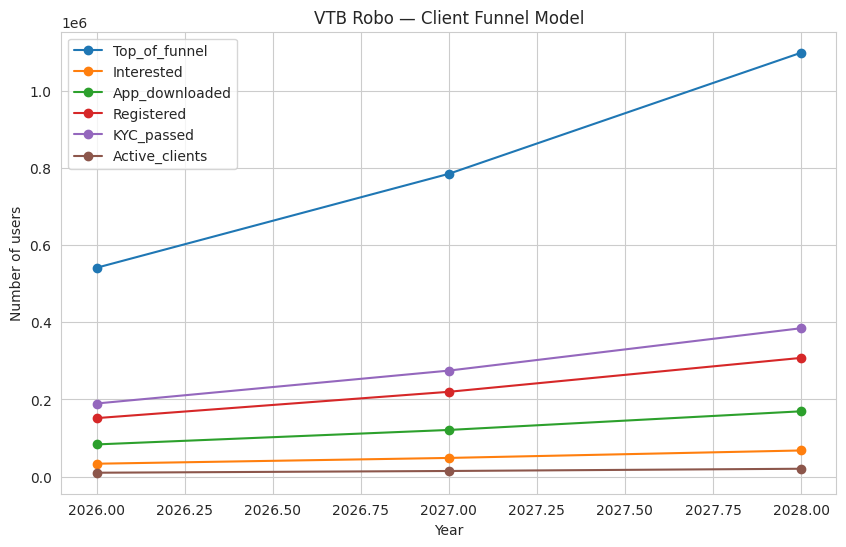

In [27]:
plt.figure(figsize=(10,6))

for col in ["Top_of_funnel", "Interested", "App_downloaded", "Registered", "KYC_passed", "Active_clients"]:
    plt.plot(funnel_df["Year"], funnel_df[col], marker="o", label=col)

plt.title("VTB Robo — Client Funnel Model")
plt.xlabel("Year")
plt.ylabel("Number of users")
plt.legend()
plt.grid(True)
plt.show()
